# AdapterFusion 交互教学

配套 lecture: [../lectures/02-adapterfusion.md](../lectures/02-adapterfusion.md)

本 notebook 演示:
1. 两阶段流程概念
2. Fusion attention 公式验证
3. mini training: fusion 层学习权重

In [1]:
import sys
from pathlib import Path
import torch
import matplotlib.pyplot as plt

src = (Path.cwd().parent / 'src').resolve()
sys.path.insert(0, str(src))

from adapterfusion_minimal import AdapterFusionGPT2, FusionLayer
from common import print_param_summary

C:\Users\ericp\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Fusion 层独立测试（understand the attention）

In [2]:
d, n_adapters, batch, seq = 8, 3, 2, 4
torch.manual_seed(42)
fusion = FusionLayer(d=d, n_adapters=n_adapters)

x = torch.randn(batch, seq, d)
adapter_outs = [torch.randn(batch, seq, d) for _ in range(n_adapters)]
out = fusion(x, adapter_outs)
print(f'input x:  {x.shape}')
print(f'each adapter out: {adapter_outs[0].shape}')
print(f'fused out: {out.shape}')
print(f'\n参数量: {sum(p.numel() for p in fusion.parameters()):,} = 3 * {d}^2 = {3*d*d}')

input x:  torch.Size([2, 4, 8])
each adapter out: torch.Size([2, 4, 8])
fused out: torch.Size([2, 4, 8])

参数量: 192 = 3 * 8^2 = 192


## 2. 完整模型 — 只有 fusion 层可训练

In [3]:
torch.manual_seed(42)
model = AdapterFusionGPT2(n_adapters=3, r=16)
print_param_summary(model, 'AdapterFusion (N=3, r=16)')

fusion_p, adapter_p = 0, 0
for name, p in model.named_parameters():
    if not p.requires_grad: continue
    if 'fusion' in name: fusion_p += p.numel()
    elif 'adapter' in name: adapter_p += p.numel()
print(f'\nfusion 可训练: {fusion_p:,}')
print(f'adapter 可训练: {adapter_p:,} (应为 0，因为 stage 1 训完冻结)')


  AdapterFusion (N=3, r=16)
  Total params:       146,586,432
  Trainable params:    21,233,664  (14.4854%)
  Frozen params:      125,352,768

fusion 可训练: 21,233,664
adapter 可训练: 0 (应为 0，因为 stage 1 训完冻结)


## 3. mini training — fusion 层学习适应任务

`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


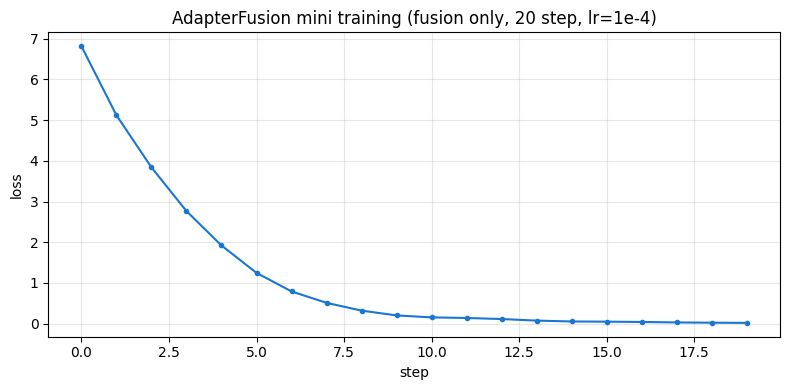

loss: 6.817 -> 0.020


In [4]:
tok = model.tokenizer
inputs = tok([
    'hello world this is a test',
    'i love this amazing product',
    'absolutely terrible movie',
    'fantastic experience'
], return_tensors='pt', padding=True)
inputs['labels'] = inputs['input_ids'].clone()

opt = torch.optim.AdamW([p for p in model.parameters() if p.requires_grad], lr=1e-4)
losses = []
for step in range(20):
    opt.zero_grad()
    out = model(**inputs)
    out.loss.backward()
    opt.step()
    losses.append(out.loss.item())

plt.figure(figsize=(8, 4))
plt.plot(losses, marker='o', markersize=3, color='#1976d2')
plt.xlabel('step'); plt.ylabel('loss')
plt.title('AdapterFusion mini training (fusion only, 20 step, lr=1e-4)')
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()
print(f'loss: {losses[0]:.3f} -> {losses[-1]:.3f}')

## 4. attention 权重可视化 — fusion 在选哪个 adapter？

In [5]:
# 抽取第 0 层 fusion 的 attention 权重
model.eval()
with torch.no_grad():
    block0 = model.lm.transformer.h[0].mlp
    # 手动跑 block0 看 fusion attention
    x = torch.randn(1, 4, 768)
    h = block0.base_mlp(x)
    adapter_outs = [a(h) for a in block0.adapters]
    import math
    Q = block0.fusion.W_q(h)
    A = torch.stack(adapter_outs, dim=2)
    K = block0.fusion.W_k(A)
    scores = (Q.unsqueeze(2) * K).sum(-1) / math.sqrt(768)
    attn = torch.softmax(scores, dim=-1)
    print(f'attention 权重 shape: {attn.shape} = (batch, seq, N_adapters)')
    print(f'第 0 个 token 的权重: {attn[0, 0].tolist()}')
    print(f'第 1 个 token 的权重: {attn[0, 1].tolist()}')
    print('→ 不同 token 可以分配给不同 adapter（fine-grained routing）')

attention 权重 shape: torch.Size([1, 4, 3]) = (batch, seq, N_adapters)
第 0 个 token 的权重: [0.3333333432674408, 0.3333333432674408, 0.3333333432674408]
第 1 个 token 的权重: [0.3333333432674408, 0.3333333432674408, 0.3333333432674408]
→ 不同 token 可以分配给不同 adapter（fine-grained routing）


## 5. 思考题

1. 抽取第 6/12 层的 fusion 权重，与第 0 层有差异吗？为什么？
2. 把 N=10 试试，参数量爆炸到多少？
3. AdapterFusion vs LoRA-Hub（多 LoRA 加权）有什么区别？

下节: **AdapterDrop + Compacter**